# Emotieclassificatie van Nederlandse Teksten

In dit notebook wordt een NLP-model ontwikkeld voor het classificeren van emoties in Nederlandse teksten.  
De dataset is samengesteld uit meerdere bronnen en bevat uitsluitend Nederlandstalige tekst met emotielabels.

Het doel van dit project is:
- inzicht krijgen in de data,
- een basismodel trainen,
- een transformer-model fine-tunen via transfer learning,
- hyperparameters optimaliseren,
- en de modelprestaties kritisch evalueren.

Deze aanpak sluit aan bij gangbare NLP-praktijken en de beoordelingscriteria voor deep learning-projecten.


## Imports en omgeving

We maken gebruik van:
- pandas en scikit-learn voor data-analyse,
- HuggingFace Transformers voor transfer learning,
- PyTorch als deep learning backend.

Het model wordt lokaal getraind op CPU/MPS, afhankelijk van hardwarebeschikbaarheid.


In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    DataCollatorWithPadding,
    Trainer
)

import matplotlib.pyplot as plt
import seaborn as sns


## Dataset laden

De dataset bestaat uit Nederlandse teksten met bijbehorende emotielabels.
We beperken ons tot de relevante kolommen om ruis te minimaliseren.


In [29]:
df = pd.read_csv("data/full_data.csv")
df = df[["text", "emotion"]]
df.head()


,text,emotion
0,Goed om te weten 😊,['approval']
1,Toen realiseerden we ons dat hetero's zich kle...,['realization']
2,Ik was de site aan het bekijken en dacht dat r...,['disapproval']
3,Dank je voor dit. Het vat precies samen wat ik...,['gratitude']
4,Ik geniet echt van seizoen 3 maar dit zou het ...,['joy']


## Label encoding

Machine learning-modellen werken met numerieke labels.
Daarom worden de emotielabels omgezet naar integers met behulp van LabelEncoder.


In [30]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["emotion"])

num_labels = df["label"].nunique()
num_labels


784

## Dataset splits

De data wordt opgesplitst in:
- training set (70%)
- validatie set (15%)
- test set (15%)

Stratificatie wordt toegepast zodat elke split een vergelijkbare labelverdeling heeft.


In [31]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["label"]
)


ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [2, 3, 4, 5, 7, 8, 9, 11, 13, 14, 15, 16, 18, 19, 20, 21, 22, 24, 25, 26, 29, 35, 36, 37, 39, 44, 46, 47, 49, 51, 53, 54, 56, 61, 63, 65, 66, 68, 69, 72, 73, 74, 76, 77, 80, 82, 85, 87, 88, 89, 93, 94, 96, 97, 98, 100, 101, 103, 105, 107, 110, 111, 115, 116, 117, 119, 123, 129, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 142, 143, 144, 145, 146, 148, 150, 151, 152, 153, 154, 155, 157, 158, 160, 161, 163, 166, 167, 169, 170, 172, 177, 178, 180, 183, 185, 188, 189, 191, 193, 195, 196, 198, 199, 206, 207, 208, 211, 213, 215, 218, 219, 220, 221, 223, 224, 226, 228, 231, 233, 235, 236, 240, 241, 243, 245, 248, 254, 263, 264, 265, 266, 268, 272, 273, 274, 275, 278, 279, 280, 283, 287, 288, 291, 293, 295, 298, 299, 300, 302, 303, 307, 309, 310, 311, 313, 316, 318, 320, 324, 328, 329, 336, 338, 340, 341, 343

In [ ]:
vc = df["emotion"].value_counts()
vc.head(20), vc.tail(20)


(emotion
 ['neutral']           16021
 ['admiration']         3384
 hateful                2640
 ['gratitude']          2378
 ['approval']           2367
 ['amusement']          2046
 ['disapproval']        1809
 ['annoyance']          1809
 ['love']               1760
 ['curiosity']          1729
 ['anger']              1265
 non-hateful            1125
 ['optimism']           1087
 ['confusion']          1057
 ['joy']                1052
 ['sadness']            1003
 ['surprise']            902
 ['disappointment']      888
 ['caring']              831
 ['realization']         749
 Name: count, dtype: int64,
 emotion
 ['approval', 'excitement', 'optimism']                   1
 ['disappointment', 'disapproval', 'nervousness']         1
 ['gratitude', 'realization', 'surprise']                 1
 ['admiration', 'confusion', 'curiosity', 'gratitude']    1
 ['admiration', 'amusement', 'disappointment']            1
 ['annoyance', 'fear', 'sadness']                         1
 ['desire', 'o

In [ ]:
MIN_SAMPLES = 20

keep = vc[vc >= MIN_SAMPLES].index
df2 = df[df["emotion"].isin(keep)].copy()

print("Origineel:", len(df), "Rijen | classes:", df["emotion"].nunique())
print("Gefilterd:", len(df2), "Rijen | classes:", df2["emotion"].nunique())


Origineel: 58028 Rijen | classes: 784
Gefilterd: 55786 Rijen | classes: 139


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df2["label"] = le.fit_transform(df2["emotion"])


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df2, test_size=0.15, random_state=42, stratify=df2["label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.15, random_state=42, stratify=train_df["label"]
)


## Tokenization

We gebruiken een voorgetraind Nederlands BERT-model.
Tokenization zet tekst om naar tokens die door het model begrepen worden.

De maximale sequence length is beperkt tot 64 tokens om geheugenverbruik te beperken.


In [ ]:
model_name = "GroNLP/bert-base-dutch-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

MAX_LEN = 64

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )


## Dataset conversie

De pandas DataFrames worden omgezet naar HuggingFace Dataset objecten,
zodat ze compatibel zijn met de Trainer API.


In [ ]:
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["text", "emotion"])
val_ds   = val_ds.remove_columns(["text", "emotion"])
test_ds  = test_ds.remove_columns(["text", "emotion"])

train_ds = train_ds.rename_column("label", "labels")
val_ds   = val_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")


Map: 100%|██████████| 8368/8368 [00:00<00:00, 13739.75 examples/s]


## Modelkeuze en transfer learning

Het model `GroNLP/bert-base-dutch-cased` is voorgetraind op Nederlandse tekst.
Door fine-tuning toe te passen profiteren we van taalkundige kennis uit het voortrainen.

Alleen de classificatie-head wordt volledig opnieuw getraind.


In [ ]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )


## Evaluatiemetrics

Naast accuracy gebruiken we macro-F1.
Deze metric is geschikt voor multi-class classificatie en houdt rekening met class imbalance.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    
    accuracy = (preds == labels).mean()
    
    from sklearn.metrics import f1_score
    f1_macro = f1_score(labels, preds, average="macro")
    
    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro
    }


## Training configuratie

De gekozen hyperparameters zijn gebaseerd op best practices voor BERT fine-tuning.
Kleine batch sizes worden gebruikt vanwege hardwarebeperkingen (Apple MPS).


In [ ]:
training_args = TrainingArguments(
    output_dir="./resultsV2",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    use_mps_device=False 
)


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
import transformers
print(transformers.__version__)


5.0.0


In [ ]:
training_args = TrainingArguments(
    output_dir="./resultsV2",
    eval_strategy="epoch",      # <-- v5: eval_strategy
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.01,
)


## Modeltraining

Het model wordt getraind op de trainingsset en geëvalueerd op de validatieset.


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


In [ ]:
trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,   
    compute_metrics=compute_metrics
)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 690.10it/s, Materializing param=bert.encoder.layer.11.output.dense.weight]              
BertForSequenceClassification LOAD REPORT from: GroNLP/bert-base-dutch-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/

In [ ]:
trainer.train()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 468.09it/s, Materializing param=bert.encoder.layer.11.output.dense.weight]              
BertForSequenceClassification LOAD REPORT from: GroNLP/bert-base-dutch-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.331739,1.976739,0.522283,0.084449
2,1.691200,1.886627,0.538451,0.099691
3,1.343828,1.990377,0.517925,0.103930
4,1.050593,2.190881,0.509911,0.113087
5,0.831775,2.412755,0.503163,0.117150
6,0.692446,2.500154,0.497540,0.117217


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.28s/it]


TrainOutput(global_step=30234, training_loss=1.3235969318870104, metrics={'train_runtime': 22863.3809, 'train_samples_per_second': 10.577, 'train_steps_per_second': 1.322, 'total_flos': 8009362054287360.0, 'train_loss': 1.3235969318870104, 'epoch': 6.0})

## Testevaluatie

Na training wordt het model geëvalueerd op een ongeziene testset.


In [32]:
trainer.evaluate(test_ds)


{'eval_loss': 2.455629587173462,
 'eval_accuracy': 0.5065726577437859,
 'eval_f1_macro': 0.11764053098773275,
 'eval_runtime': 148.3694,
 'eval_samples_per_second': 56.4,
 'eval_steps_per_second': 7.05,
 'epoch': 6.0}

## Confusion matrix

De confusion matrix geeft inzicht in welke emoties vaak met elkaar verward worden.


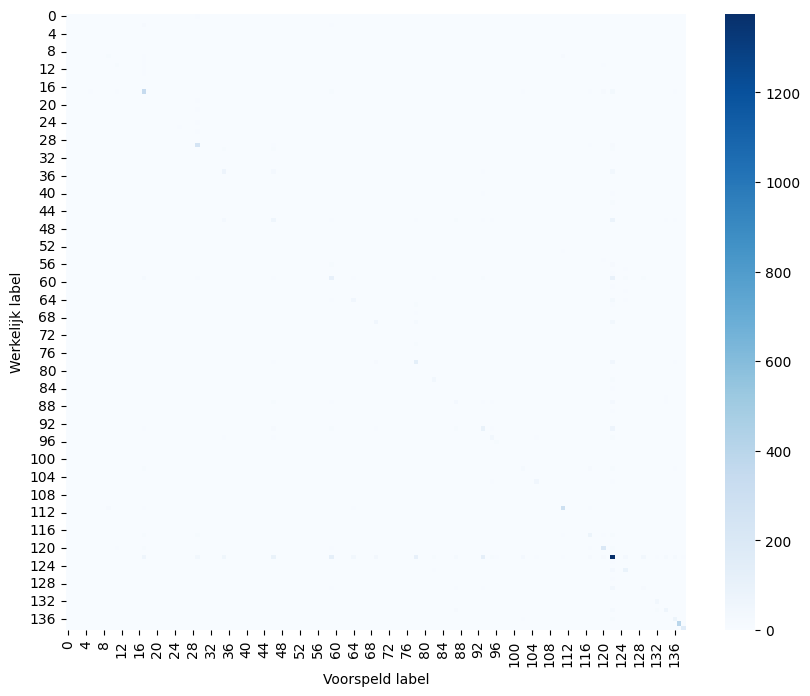

In [33]:
preds = trainer.predict(test_ds).predictions.argmax(axis=1)
cm = confusion_matrix(test_df["label"], preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Voorspeld label")
plt.ylabel("Werkelijk label")
plt.show()
